In [3]:
# Another Sum

In [1]:
from matplotlib.path import Path as mPath
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely.geometry import Point, Polygon
from shapely.plotting import plot_polygon
import xarray as xr

from scipy.optimize import curve_fit

In [75]:
output = pd.read_csv('/home/sallen/MEOPAR/ANALYSIS/analysis-susan/notebooks/Metro/PBDE_99_daily_projected_2030.csv', 
                     parse_dates=[0], header=0, names=['Date', 'PBDE_99'])

,Date,PBDE_99
0,1970-07-01,0.000000
1,1970-07-02,0.000000
2,1970-07-03,0.000000
3,1970-07-04,0.000000
4,1970-07-05,0.000000
...,...,...
22094,2030-12-27,0.689525
22095,2030-12-28,0.689295
22096,2030-12-29,0.689065
22097,2030-12-30,0.688834


In [6]:
output['year'] = output['Date'].dt.year
discharge = output.groupby('year')['PBDE_99'].mean()
discharge[0:5]

year
1970    0.000000
1971    0.000213
1972    0.005138
1973    0.014280
1974    0.027694
Name: PBDE_99, dtype: float64

In [2]:
# Maximum output
max_output = pd.read_csv('PBDEs_max_predicted_discharge.csv', parse_dates=[0], header=0)
max_output['year'] = max_output['Unnamed: 0'].dt.year
discharge = max_output.groupby('year')['BDE-99'].mean()
discharge[0:5]

year
1970    0.000000
1971    0.001926
1972    0.011264
1973    0.023517
1974    0.046056
Name: BDE-99, dtype: float64

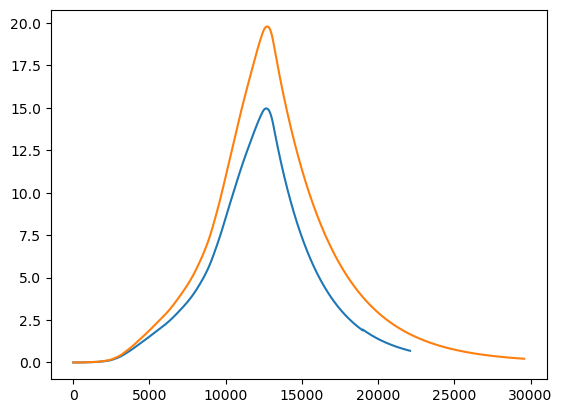

In [99]:
output['PBDE_99'].plot();
max_output['BDE-99'].plot();

In [4]:
year1 = xr.open_dataset('Simulation_V4_year_1.nc')
year2 = xr.open_dataset('Simulation_V4_year_2.nc')
year3 = xr.open_dataset('Simulation_V4_year_3.nc')
year4 = xr.open_dataset('Simulation_V4_year_4.nc')
year5 = xr.open_dataset('Simulation_V4_year_5.nc')

In [3]:
def pad_year(year3, conversion, ts_full_yr1):
    ts_full_yr3d = (year3.status == 2).sum(axis=0) * conversion
    ts_full_yr3 = np.zeros_like(ts_full_yr1)
    ts_full_yr3[1::2] = ts_full_yr3d
    ts_full_yr3[0] = 0.5 * (ts_full_yr3[1] + ts_full_yr2[-1])
    ts_full_yr3[2::2] = 0.5 * (ts_full_yr3[1:-2:2] + ts_full_yr3[3::2])
    return ts_full_yr3

year1

In [5]:
conversion = 1 / 96 / 1000# 1 g per day = 96 particles, change to kg,
ts_full_yr1 = (year1.status == 2).sum(axis=0) * conversion
ts_full_yr2 = (year2.status == 2).sum(axis=0) * conversion
ts_full_yr3 = pad_year(year3, conversion, ts_full_yr1)
ts_full_yr4 = pad_year(year4, conversion, ts_full_yr1)
ts_full_yr5 = pad_year(year5, conversion, ts_full_yr1)

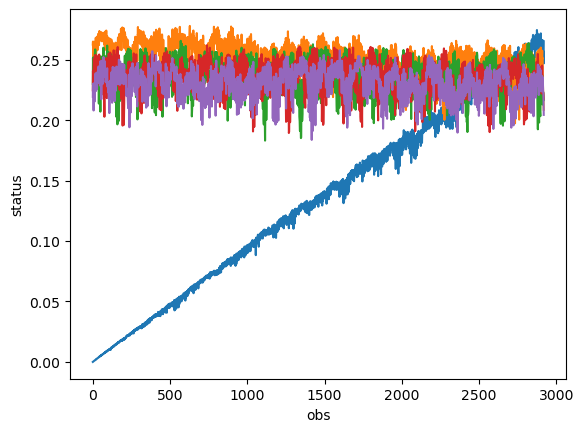

In [6]:
fig, ax = plt.subplots(1, 1)
ts_full_yr1.plot(ax=ax);
ts_full_yr2.plot(ax=ax);
#ax.plot(np.arange(0, 2920, 2), ts_full_yr3d);
ax.plot(ts_full_yr3);
ax.plot(ts_full_yr4);
ax.plot(ts_full_yr5);

In [8]:
one_year = 365 * 8
zero_values = np.zeros((2030-1970+1)*one_year)
one_values = np.zeros_like(zero_values)
two_values = np.zeros_like(zero_values)
three_values = np.zeros_like(zero_values)
four_values = np.zeros_like(zero_values)
for year in range(1970, 2030):
    zero_values[(year-1970)*one_year:(year-1970+1)*one_year] = (
        discharge[year] * ts_full_yr1)
for year in range(1971, 2030):
    one_values[(year-1970)*one_year:(year-1970+1)*one_year] = (
        zero_values[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge[year-1] * ts_full_yr2)
for year in range(1972, 2030):
    two_values[(year-1970)*one_year:(year-1970+1)*one_year] = (
        one_values[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge[year-2] * ts_full_yr3)
for year in range(1973, 2030):
    three_values[(year-1970)*one_year:(year-1970+1)*one_year] = (
        two_values[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge[year-3] * ts_full_yr4)
for year in range(1974, 2030):
    four_values[(year-1970)*one_year:(year-1970+1)*one_year] = (
        three_values[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge[year-4] * ts_full_yr5)

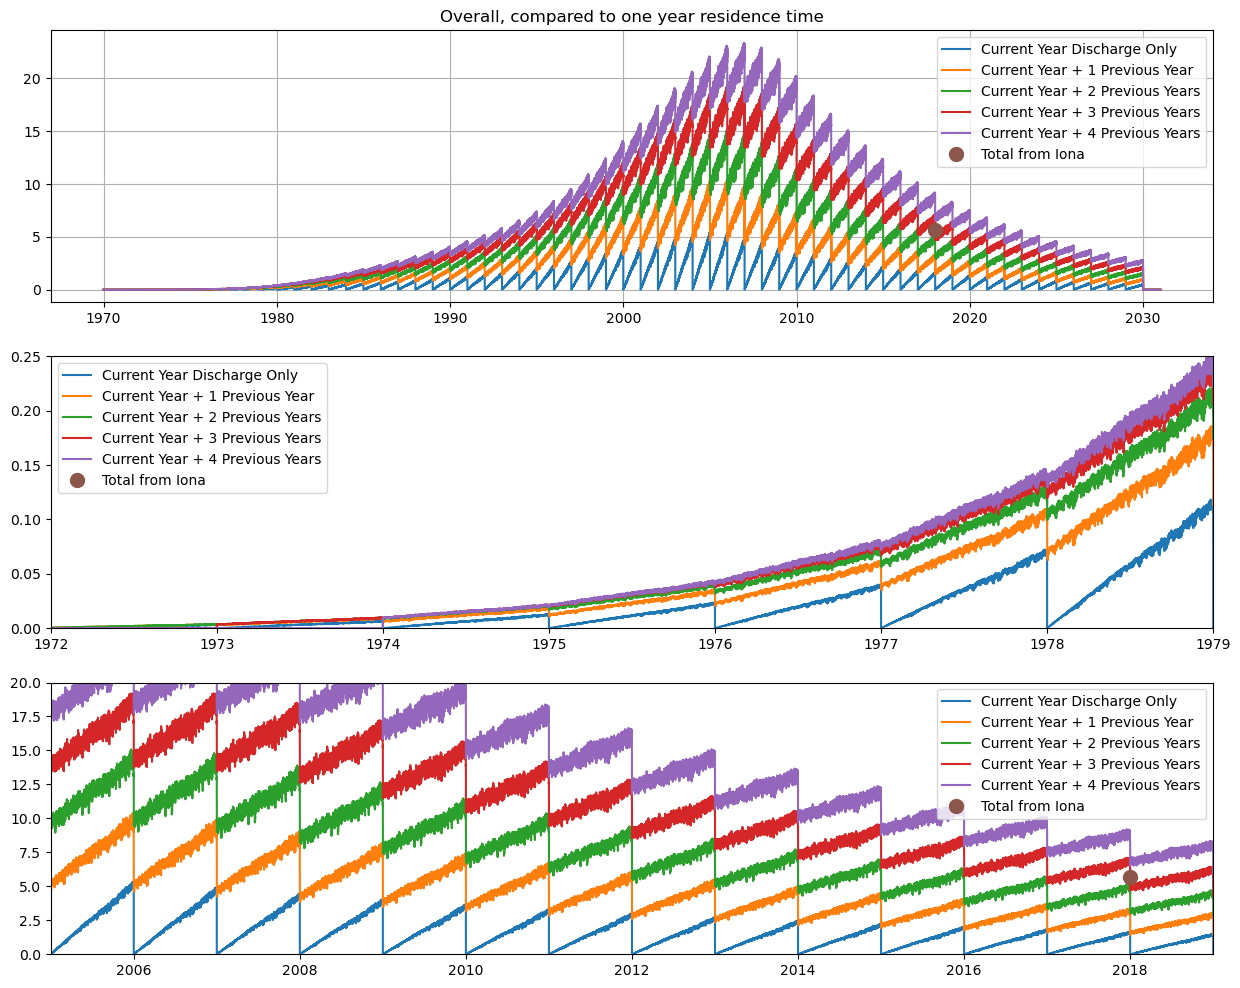

In [12]:
fig, axs = plt.subplots(3, 1, figsize=(15, 12))
for ax in axs:
    ax.plot(np.arange(1970, 2031, 1/(8*365)), zero_values, label="Current Year Discharge Only");
    ax.plot(np.arange(1970, 2031, 1/(8*365)), one_values, label="Current Year + 1 Previous Year");
    ax.plot(np.arange(1970, 2031, 1/(8*365)), two_values, label="Current Year + 2 Previous Years");
    ax.plot(np.arange(1970, 2031, 1/(8*365)), three_values, label="Current Year + 3 Previous Years")
    ax.plot(np.arange(1970, 2031, 1/(8*365)), four_values, label="Current Year + 4 Previous Years")
    ax.plot([2018], [71/2.5/5], 'o', markersize=10, label='Total from Iona'); # 2.5 proportion from Iona, 1/5 part from PBDE-99?
    ax.legend();
axs[1].set_xlim(1972, 1979);
axs[1].set_ylim(0, 0.25);
axs[2].set_xlim(2005, 2019);
axs[2].set_ylim(0, 20);

axs[0].grid();
axs[0].set_title('Overall, compared to one year residence time');

# At Station S4-1.5 #

In [13]:
def def_poly(mask):
    # boxes from Vicente: Regions_functions_V2.py
    # Southern Strait: Subregion
    Sx1_1, Sy1_1 = [202, 292], [505, 505]
    Sx1_4, Sy1_4 = [238, 245], [465, 410]
    Sx1_5, Sy1_5 = [302, 280], [410, 470]

    (S1_lon_1, S1_lat_1) = ([mask.nav_lon[Sy1_1[0],Sx1_1[0]].values, mask.nav_lon[Sy1_1[1],Sx1_1[1]].values], 
                            [mask.nav_lat[Sy1_1[0],Sx1_1[0]].values, mask.nav_lat[Sy1_1[1],Sx1_1[1]].values])
    (S1_lon_4, S1_lat_4) = ([mask.nav_lon[Sy1_4[0],Sx1_4[0]].values, mask.nav_lon[Sy1_4[1],Sx1_4[1]].values], 
                            [mask.nav_lat[Sy1_4[0],Sx1_4[0]].values, mask.nav_lat[Sy1_4[1],Sx1_4[1]].values])
    (S1_lon_5, S1_lat_5) = ([mask.nav_lon[Sy1_5[0],Sx1_5[0]].values, mask.nav_lon[Sy1_5[1],Sx1_5[1]].values], 
                            [mask.nav_lat[Sy1_5[0],Sx1_5[0]].values, mask.nav_lat[Sy1_5[1],Sx1_5[1]].values])

    polygon_lon_lat_S1 = [
    (S1_lon_1[0], S1_lat_1[0]),
    (S1_lon_1[1], S1_lat_1[1]),
    (S1_lon_5[1], S1_lat_5[1]),
    (S1_lon_4[0], S1_lat_4[0])
    ]
    polygon_coors_S1 = Polygon(polygon_lon_lat_S1)
    polygon_path_S1 = mPath(polygon_lon_lat_S1)
    

    return polygon_coors_S1, polygon_path_S1

In [14]:
def find_poly_volume(mask, bathy, top_depth):
    polygon_coors_S1, polygon_path_S1 = def_poly(mask)

    my_mask_S = np.zeros((898, 398))

    # just subset to make it run faster
    for ii in range(400, 510):
        for jj in range (200, 310):
            if (Point(bathy.nav_lon[ii, jj].values, bathy.nav_lat[ii, jj].values)).within(polygon_coors_S1):
                my_mask_S[ii, jj] = 1

    volume_S = mask.tmask[0] * my_mask_S * mask.e1t[0] * mask.e2t[0] * mask.e3t_0[0]
    return polygon_coors_S1, polygon_path_S1, volume_S[top_depth:].sum()

In [15]:
bathy = xr.open_dataset('/home/sallen/MEOPAR/grid/bathymetry_202108.nc')
mask = xr.open_dataset('/home/sallen/MEOPAR/grid/mesh_mask202108.nc')
top_depth = 24

In [16]:
polygon_coors_S1, polygon_path_S1, volume_S = find_poly_volume(mask, bathy, top_depth)

In [17]:
def count_S1_values(yearn, nobs, skip, top_depth, mask, polygon_path_S1):

    count = np.zeros((nobs))
    
    status_mask = yearn.status[::skip] == 2
    depth_mask = yearn.z[::skip] > mask.gdepw_1d[0, top_depth]
    lat_mask = (yearn.lat[::skip] > 49.1485) & (yearn.lat[::skip] < 49.4075)
    lon_mask = (yearn.lon[::skip] > -124.0322) & (yearn.lon[::skip] < -123.5103)

    lats = np.ma.masked_array(yearn.lat[::skip], 
                              mask=1 - status_mask * depth_mask * lat_mask * lon_mask)
    lons = np.ma.masked_array(yearn.lon[::skip], 
                              mask = 1 - status_mask * depth_mask * lat_mask * lon_mask)

    for it in range(nobs):
        points = np.stack([lons[:, it].compressed(), lats[:, it].compressed()]).transpose()
        count[it] = polygon_path_S1.contains_points(points).sum()

    return count

For skip of 1, maximum counts are 5982.0


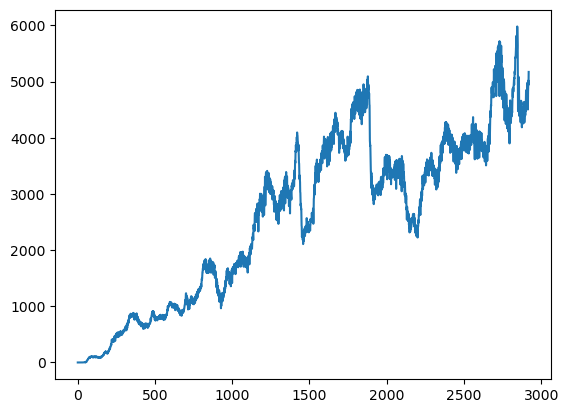

In [17]:
ntraj, nobs = year1.status.values.shape
skip = 1
count = count_S1_values(year1, nobs, skip, top_depth, mask, polygon_path_S1)

plt.plot(count)
print (f'For skip of {skip}, maximum counts are {count.max()}')

In [18]:
np.savetxt('S1_counts_year1.txt', count)

For year 2, skip of 1, maximum counts are 7303.0


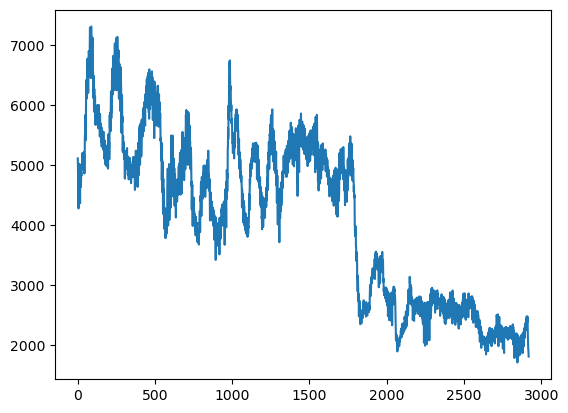

In [19]:
count = count_S1_values(year2, nobs, skip, top_depth, mask, polygon_path_S1)

plt.plot(count)
print (f'For year 2, skip of {skip}, maximum counts are {count.max()}')
np.savetxt('S1_counts_year2.txt', count)

In [20]:
countd = count_S1_values(year3, 1460, skip, top_depth, mask, polygon_path_S1)

For year 3, skip of 1, maximum counts are 3262.0


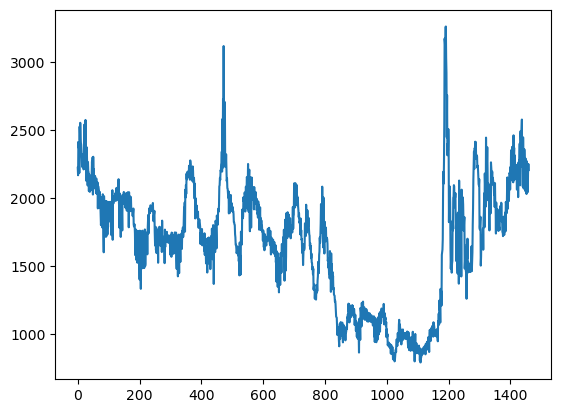

In [21]:
plt.plot(countd)
print (f'For year 3, skip of {skip}, maximum counts are {countd.max()}')
np.savetxt('S1_counts_year3.txt', countd)

In [54]:
countd = count_S1_values(year4, 1460, skip, top_depth, mask, polygon_path_S1)

For year 3, skip of 1, maximum counts are 2453.0


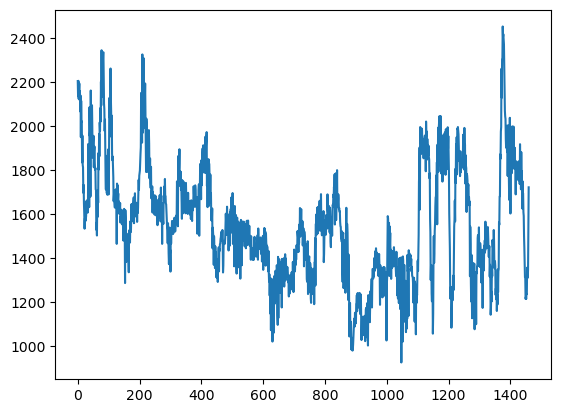

In [55]:
plt.plot(countd)
print (f'For year 3, skip of {skip}, maximum counts are {countd.max()}')
np.savetxt('S1_counts_year4.txt', countd)

In [19]:
countd = count_S1_values(year5, 1460, 1, top_depth, mask, polygon_path_S1)

For year 5, skip of 1, maximum counts are 2473.0


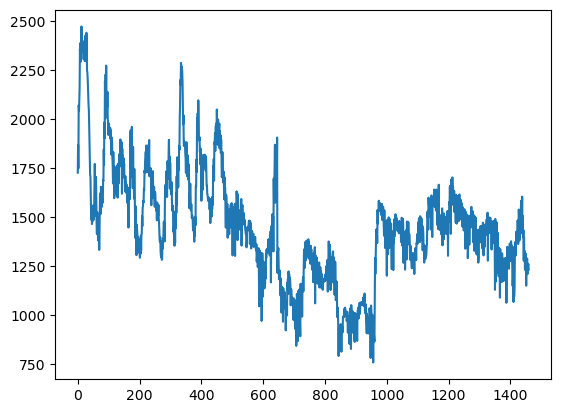

In [21]:
plt.plot(countd)
print (f'For year 5, skip of {1}, maximum counts are {countd.max()}')
np.savetxt('S1_counts_year5.txt', countd)

In [22]:
def pad_S1 (count_y1, count_y2, count_y3d):
    count_y3 = np.zeros_like(count_y1)
    count_y3[1::2] = count_y3d
    count_y3[0] = 0.5 * (count_y3[1] + count_y2[-1])
    count_y3[2::2] = 0.5 * (count_y3[1:-2:2] + count_y3[3::2])
    return count_y3

In [23]:
count_y1 = np.loadtxt('S1_counts_year1.txt')
count_y2 = np.loadtxt('S1_counts_year2.txt')
count_y3d = np.loadtxt('S1_counts_year3.txt')
count_y3 = pad_S1(count_y1, count_y2, count_y3d)
count_y4d = np.loadtxt('S1_counts_year4.txt')
count_y4 = pad_S1(count_y1, count_y3, count_y4d)
count_y5d = np.loadtxt('S1_counts_year5.txt')
count_y5 = pad_S1(count_y1, count_y4, count_y5d)

In [24]:
print (count_y1.shape, count_y5.shape)
volume_S

(2920,) (2920,)


<xarray.DataArray ()> Size: 8B
array(1.09140927e+11)

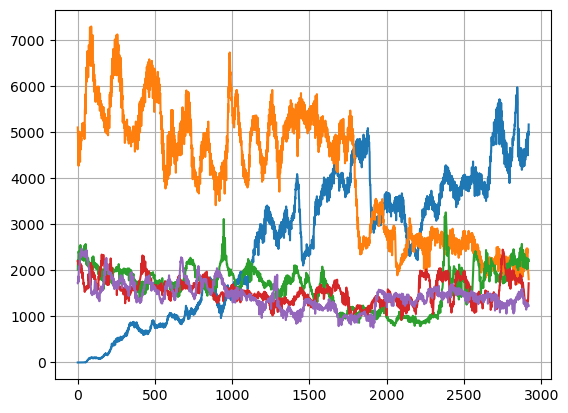

In [26]:
plt.plot(count_y1)
plt.plot(count_y2)
plt.plot(count_y3)
plt.plot(count_y4)
plt.plot(count_y5)
plt.grid()

In [27]:
one_year = 365 * 8
zero_values = np.zeros((2030-1970+1)*one_year)
one_values = np.zeros_like(zero_values)
two_values = np.zeros_like(zero_values)
three_values = np.zeros_like(zero_values)
four_values = np.zeros_like(zero_values)
for year in range(1970, 2030):
    zero_values[(year-1970)*one_year:(year-1970+1)*one_year] = (
        discharge[year] * count_y1 * conversion / volume_S.values)
for year in range(1971, 2030):
    one_values[(year-1970)*one_year:(year-1970+1)*one_year] = (
        zero_values[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge[year-1] * count_y2 * conversion / volume_S.values)
for year in range(1972, 2030):
    two_values[(year-1970)*one_year:(year-1970+1)*one_year] = (
        one_values[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge[year-2] * count_y3 * conversion / volume_S.values)
for year in range(1973, 2030):
    three_values[(year-1970)*one_year:(year-1970+1)*one_year] = (
        two_values[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge[year-3] * count_y4 * conversion / volume_S.values)
for year in range(1974, 2030):
    four_values[(year-1970)*one_year:(year-1970+1)*one_year] = (
        three_values[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge[year-4] * count_y5 * conversion / volume_S.values)

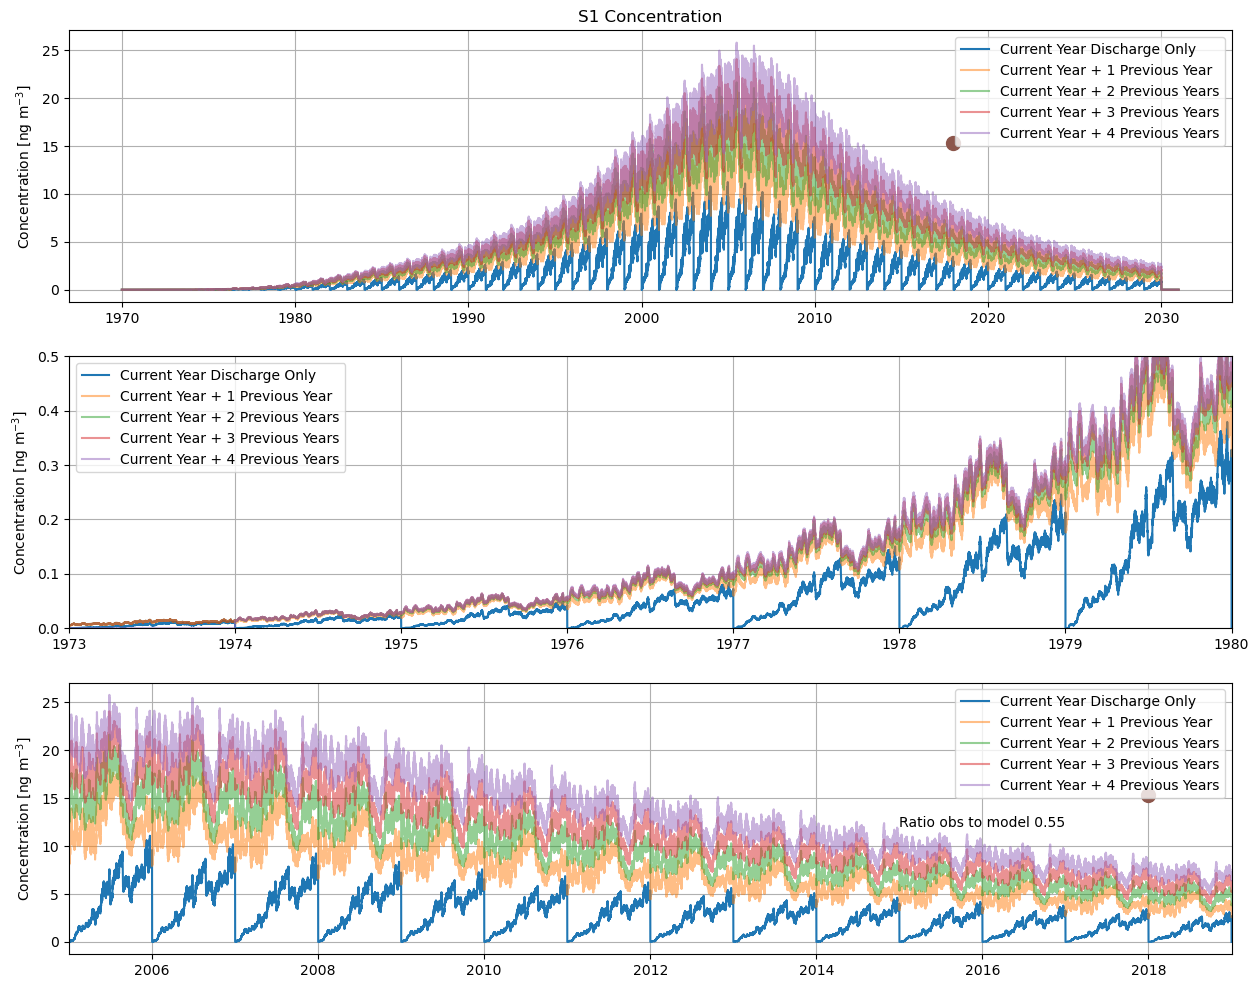

In [29]:
fig, axs = plt.subplots(3, 1, figsize=(15, 12))
for ax in axs:
    ax.plot(np.arange(1970, 2031, 1/(8*365)), zero_values*1e12, label="Current Year Discharge Only");
    ax.plot(np.arange(1970, 2031, 1/(8*365)), one_values*1e12, label="Current Year + 1 Previous Year", alpha=0.5);
    ax.plot(np.arange(1970, 2031, 1/(8*365)), two_values*1e12, label="Current Year + 2 Previous Years", alpha=0.5);
    ax.plot(np.arange(1970, 2031, 1/(8*365)), three_values*1e12, label="Current Year + 3 Previous Years", alpha=0.5)
    ax.plot(np.arange(1970, 2031, 1/(8*365)), four_values*1e12, label="Current Year + 4 Previous Years", alpha=0.5)
    ax.set_ylabel('Concentration [ng m$^{-3}$]')
    ax.legend()
    ax.grid()
    ax.plot([2018], [(70.2-31.9)/2.5], 'o', markersize=10, label='Minimum Expected from Iona')
axs[1].set_xlim(1973, 1980)
axs[1].set_ylim(0, 0.5)
axs[2].set_xlim(2005, 2019)
#axs[2].set_ylim(0, 2);


axs[0].set_title('S1 Concentration');
axs[2].text(2015, 12, f'Ratio obs to model {four_values[(2018-1970)*8*365:(2019-1970)*8*365].max()*1e12/((70.2-31.9)/2.5):.2f}');

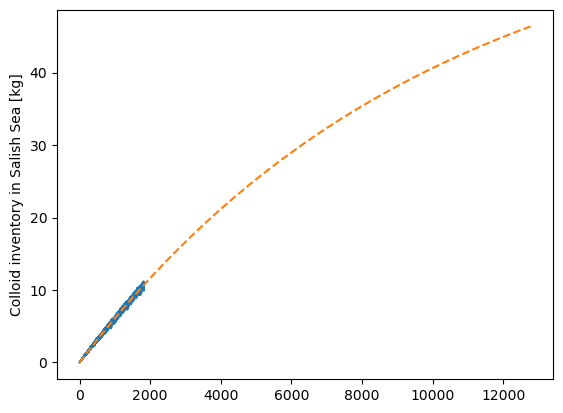

In [36]:
full_ts = np.zeros((2920*5))
full_ts[0:2920] = ts_full_yr1 * discharge[2018-5]
full_ts[2920:2920*2] = (ts_full_yr1 + ts_full_yr2) * discharge[2018-5]
full_ts[2920*2:2920*3] = (ts_full_yr1 + ts_full_yr2 + ts_full_yr3) * discharge[2018-5]
full_ts[2920*3:2920*4] = (ts_full_yr1 + ts_full_yr2 + ts_full_yr3 + ts_full_yr4) * discharge[2018-5]
full_ts[2920*4:] = (ts_full_yr1 + ts_full_yr2 + ts_full_yr3 + ts_full_yr4 + ts_full_yr5) * discharge[2018-5]
plt.plot(np.arange(2920*5)*365/2920, full_ts)
plt.plot(np.arange(2920*5)*365/2920*7, curve(np.arange(2920*5)*365/2920*7, popt[0], popt[1]), '--')
plt.ylabel('Colloid inventory in Salish Sea [kg]');

In [31]:
def curve(t, goal, decay):
    return goal * (1. - np.exp(-t/decay))

In [34]:
popt, pcov = curve_fit(curve, np.arange(2920*5)*365/2920, full_ts, p0=[14, 365])

In [37]:
popt[0], popt[1]/365

(64.38985900764096, 27.49056757638026)

Two years: (17.41713421464484, 10.90945107682955)  
Three years: (24.445575662553964, 15.61734887155874) 
Four years: (52.29210399365346, 22.076422763801034)  
Five years: (64.38985900764096, 27.49056757638026)  

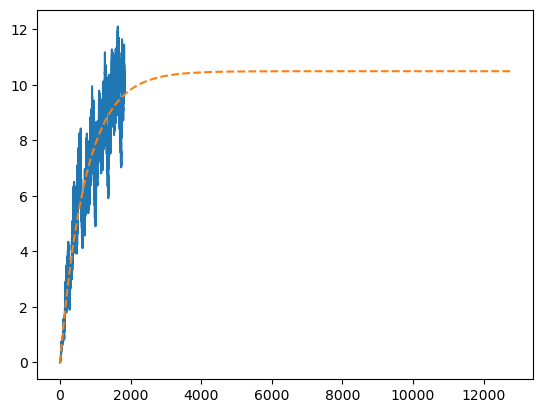

In [42]:
S1_ts = np.zeros((2920*5))
S1_ts[0:2920] = count_y1 * conversion / volume_S.values * 1e12 * discharge[2018-5]
S1_ts[2920:2920*2] = (count_y1 + count_y2) * conversion / volume_S.values * 1e12 * discharge[2018-5]
S1_ts[2920*2:2920*3] = (count_y1 + count_y2 + count_y3) * conversion / volume_S.values * 1e12 * discharge[2018-5]
S1_ts[2920*3:2920*4] = (count_y1 + count_y2 + count_y3 + count_y4) * conversion / volume_S.values * 1e12 * discharge[2018-5]
S1_ts[2920*4:2920*5] = (count_y1 + count_y2 + count_y3 + count_y4 + count_y5) * conversion / volume_S.values * 1e12 * discharge[2018-5]
plt.plot(np.arange(2920*5)*365/2920, S1_ts)
plt.plot(np.arange(2920*5)*365/2920*7, curve(np.arange(2920*5)*365/2920*7, poptS[0], poptS[1]), '--');

In [40]:
poptS, pcovS = curve_fit(curve, np.arange(2920*5)*365/2920, S1_ts, p0=[14, 365])

In [41]:
poptS[0], poptS[1]/365

(10.493062550356187, 1.9832679109632088)

Two years: 5.329101814691215, 1.2955400430965205)  
Three years: (5.478982494839365, 1.3371411556610349)  
Four years: (6.097803282826282, 1.6150681163900362)  
Four years with maximum output: (9.396547564976244, 1.615069864192495)  
Five years: (10.493062550356187, 1.9832679109632088)

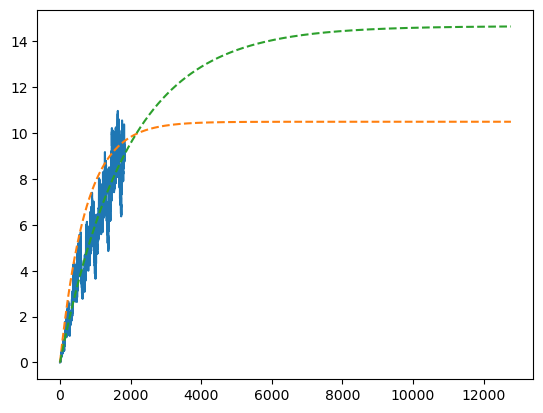

In [46]:
S1_ats = np.zeros((2920*5))
S1_ats[0:2920] = count_y1 * conversion / volume_S.values * 1e12 * discharge[2018]
S1_ats[2920:2920*2] = (count_y1 + count_y2) * conversion / volume_S.values * 1e12 * discharge[2018-1]
S1_ats[2920*2:2920*3] = (count_y1 + count_y2 + count_y3) * conversion / volume_S.values * 1e12 * discharge[2018-2]
S1_ats[2920*3:2920*4] = (count_y1 + count_y2 + count_y3 + count_y4) * conversion / volume_S.values * 1e12 * discharge[2018-3]
S1_ats[2920*4:2920*5] = (count_y1 + count_y2 + count_y3 + count_y4 + count_y5) * conversion / volume_S.values * 1e12 * discharge[2018-4]
plt.plot(np.arange(2920*5)*365/2920, S1_ats)
plt.plot(np.arange(2920*5)*365/2920*7, curve(np.arange(2920*5)*365/2920*7, poptS[0], poptS[1]), '--');
plt.plot(np.arange(2920*5)*365/2920*7, curve(np.arange(2920*5)*365/2920*7, poptA[0], poptA[1]), '--');

In [44]:
poptA, pcovA = curve_fit(curve, np.arange(2920*5)*365/2920, S1_ats[:5*2920], p0=[14, 365])

In [45]:
poptA[0], poptA[1]/365

(14.662762642248786, 5.193820761677435)

Five years: (14.662762642248786, 5.193820761677435)  
Four years: (10.048945532713487, 3.121881955407078)  
Three years: (7.383987984456616, 2.016866564013346)  
Two years: (6.2268255135023995, 1.6241844574558146)  
One year: (4.137721316403167, 1.1495851221292923)  

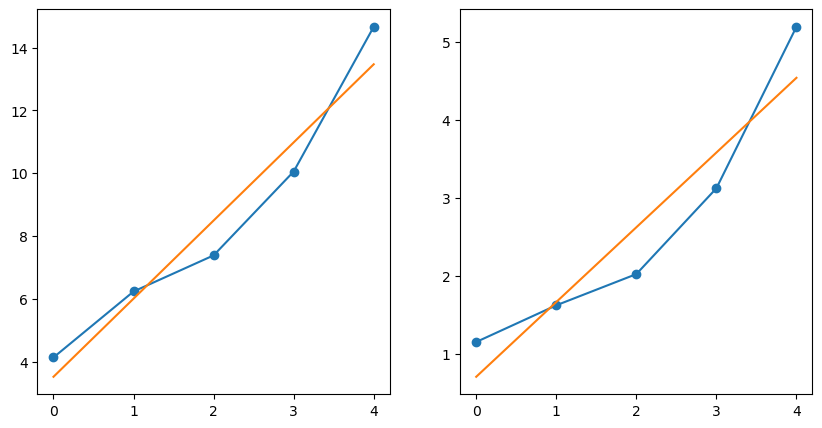

In [51]:
array1 = np.array([0, 1, 2, 3, 4])
array2 = np.array([4.13, 6.23, 7.38, 10.05, 14.66])
array3 = np.array([1.15, 1.62, 2.02, 3.12, 5.19])
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].plot(array1, array2, '-o')
axs[0].plot(array1, mx[0]*array1+mx[1], '-')
axs[1].plot(array1, array3, '-o');
axs[1].plot(array1, mx2[0]*array1+mx2[1], '-');

In [48]:
def myline(t, m, b):
    return m*t + b

In [49]:
mx, stuff = curve_fit(myline, array1, array2, p0=[1, 4])

In [50]:
mx2, stuff = curve_fit(myline, array1, array3, p0=[0.6, 1])

In [137]:
mx2

array([0.631, 1.031])